Inputs: qa 12 1.2 True
Dataset  will be saved from jobs.
Dataset loaded
Using columns: Row_id Age
Dataset dataset_output will be saved from jobs.
Artifact 'STRING' with value 'qa' will be saved from jobs.
Artifact 'INT' with value '12' will be saved from jobs.
Artifact 'FLOAT' with value '1.2' will be saved from jobs.
Artifact 'BOOLEAN' with value 'True' will be saved from jobs.
Artifact 'MODEL_COEF' with value '[0.02574744698978795]' will be saved from jobs.
Artifact 'MODEL_INTERCEPT' with value '33.26826452905812' will be saved from jobs.


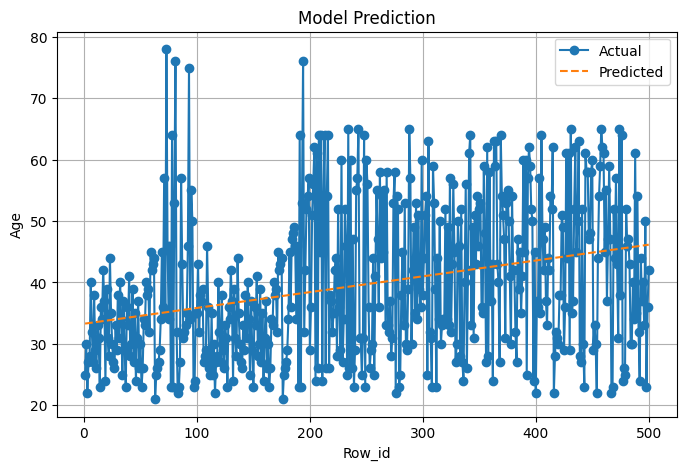

AttributeError: 'WarpDrive' object has no attribute 'save_img'

In [8]:
!pip install -r requirements.txt
# =========================
from warpdrive.warpdrive import WarpDrive
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# INIT
# =========================
wd = WarpDrive()

# =========================
# GET INPUTS
# =========================
dataset1 = wd.get_args("dataset1")
string1 = wd.get_args("string1")
int1 = wd.get_args("int1")
float1 = wd.get_args("float1")
bool1 = wd.get_args("bool1")

print("Inputs:", string1, int1, float1, bool1)

# =========================
# LOAD DATASET (SAFE)
# =========================
try:
    df = wd.create_df(dataset1)
    print("Dataset loaded")
except:
    print("Using fallback dataset")
    df = pd.DataFrame({
        "x": [1, 2, 3, 4, 5, 6],
        "y": [10, 15, 7, 12, 18, 24]
    })

# =========================
# MAKE SURE DATA IS VALID
# =========================
if not isinstance(df, pd.DataFrame) or df.empty:
    df = pd.DataFrame({
        "x": [1, 2, 3, 4, 5, 6],
        "y": [10, 15, 7, 12, 18, 24]
    })

# Ensure at least 2 columns
if len(df.columns) < 2:
    df["y"] = np.arange(len(df))

# =========================
# SELECT COLUMNS (NO ERROR)
# =========================
x_col = df.columns[0]
y_col = df.columns[1]

print("Using columns:", x_col, y_col)

# =========================
# MODEL
# =========================
X = df[[x_col]].values
y = df[y_col].values

model = LinearRegression()
model.fit(X, y)

# Predict
df["prediction"] = model.predict(X)

# =========================
# SAVE DATASET
# =========================
wd.create_df(df, "dataset_output")

# =========================
# SAVE INPUTS / OUTPUTS
# =========================
wd.add_output_artifact("STRING", str(string1))
wd.add_output_artifact("INT", int(int1))
wd.add_output_artifact("FLOAT", float(float1))
wd.add_output_artifact("BOOLEAN", bool(bool1))

# Model info (convert to SAFE types)
wd.add_output_artifact("MODEL_COEF", str(model.coef_.tolist()))
wd.add_output_artifact("MODEL_INTERCEPT", float(model.intercept_))

# =========================
# GRAPH
# =========================
plt.figure(figsize=(8, 5))

plt.plot(df[x_col], df[y_col], marker='o', label="Actual")
plt.plot(df[x_col], df["prediction"], linestyle='--', label="Predicted")

plt.title("Model Prediction")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend()
plt.grid(True)

plt.savefig("output_chart.png", dpi=300)
plt.show()

# Save graph
wd.save_graph(plt)
wd.save_image(plt)

# =========================
# DONE
# =========================
print("✅ Job completed successfully")